In [1]:
import maboss
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logit, expit
import numpy.polynomial as poly

### Simulation with pyMaBoSS

In [2]:
sim_long = maboss.PopSimulation("ICD_phenomenological/ICD_phenomenologicalPM.pbnd", "ICD_phenomenological/ICD_phenomenologicalPMNewICBig.cfg")
sim_long.set_custom_pop_output("#cell(DC) > 0 ? (#cell(DC -- TCell)+#cell(TCell)) > 0 ? (#cell(DC -- TCell)+#cell(TCell))/#cell(DC) : -1 : -1;")
res_long = sim_long.run()

In [3]:
sim_long5Cl = maboss.PopSimulation("ICD_phenomenological/ICD_phenomenologicalPM.pbnd", "ICD_phenomenological/ICD_phenomenologicalPMNewICBig.cfg")
sim_long5Cl.cmaboss_sim.set_custom_pop_output("#cell(DC) > 0 ? (#cell(DC -- TCell)+#cell(TCell)) > 0 ? (#cell(DC -- TCell)+#cell(TCell))/#cell(DC) : -1 : -1;")
sim_long5Cl.param["$clonalExpansion"]=(5/12)
res_long5Cl = sim_long5Cl.run()

In [4]:
sim_long10Cl = maboss.PopSimulation("ICD_phenomenological/ICD_phenomenologicalPM.pbnd", "ICD_phenomenological/ICD_phenomenologicalPMNewICBig.cfg")
sim_long10Cl.cmaboss_sim.set_custom_pop_output("#cell(DC) > 0 ? (#cell(DC -- TCell)+#cell(TCell)) > 0 ? (#cell(DC -- TCell)+#cell(TCell))/#cell(DC) : -1 : -1;")
sim_long10Cl.param["$clonalExpansion"]=(10/12)
res_long10Cl = sim_long10Cl.run()

In [5]:
serie = res_long.get_last_custom_states_probtraj(prob_cutoff=0)
serie5Cl = res_long5Cl.get_last_custom_states_probtraj(prob_cutoff=0)
serie10Cl = res_long10Cl.get_last_custom_states_probtraj(prob_cutoff=0)

<Axes: >

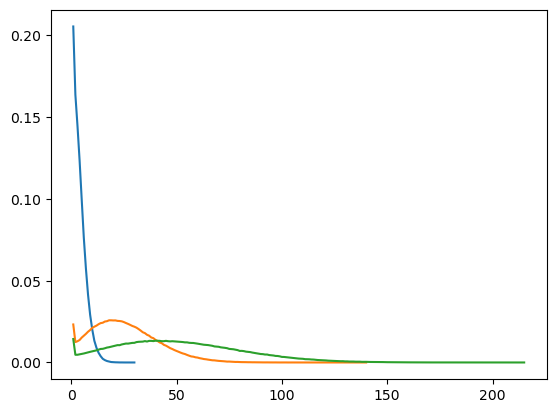

In [6]:
serie.plot()
serie5Cl.plot()
serie10Cl.plot()

In [7]:
degree=6
func = poly.Polynomial.fit(serie.index, logit(serie.values), deg=degree)
func5Cl = poly.Polynomial.fit(serie5Cl.index, logit(serie5Cl.values), deg=degree)
func10Cl = poly.Polynomial.fit(serie10Cl.index, logit(serie10Cl.values), deg=degree)

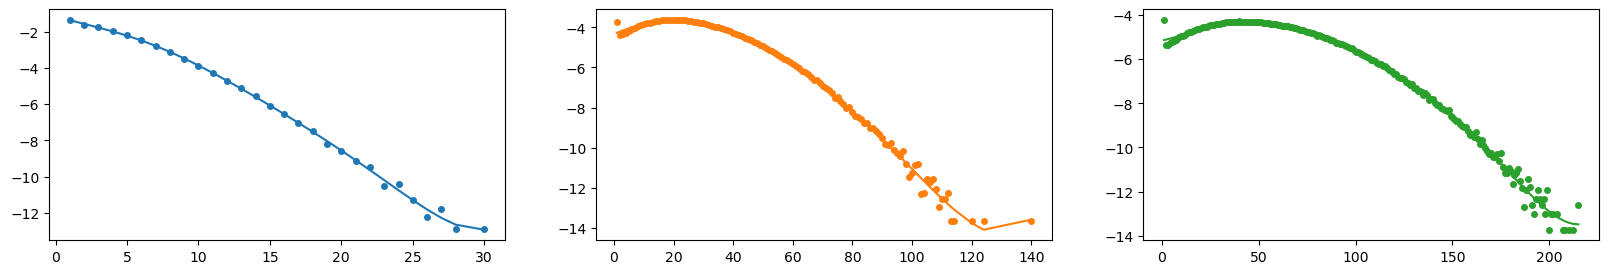

In [8]:
fig, ax = plt.subplots(1,3, figsize=(20,3))
ax[0].plot(serie.index, logit(serie.values), marker='o', markersize=4, color='C0', linestyle='None')
ax[0].plot(serie.index,  func(serie.index), marker=None, color='C0', linestyle='-')#, label=str(func))
# ax[0].legend()

ax[1].plot(serie5Cl.index, logit(serie5Cl.values), marker='o', markersize=4, color='C1', linestyle='None')
ax[1].plot(serie5Cl.index, func5Cl(serie5Cl.index), marker=None, color='C1', linestyle='-')#, label=str(func5Cl))
# ax[1].legend()

ax[2].plot(serie10Cl.index, logit(serie10Cl.values), marker='o', markersize=4, color='C2', linestyle='None')
ax[2].plot(serie10Cl.index, func10Cl(serie10Cl.index), marker=None, color='C2', linestyle='-')#, label=str(func10Cl))
# ax[2].legend()

In [9]:
exp_data = pd.read_csv("ICD_phenomenological/TratioDC.csv", sep="\t")
exp_data_filtered = exp_data[(exp_data["Day"] == 11) & (exp_data["Treatment"] == "MTX")]["TratioDC"]

In [10]:
log_likelyhood = np.log(np.prod(expit(func(exp_data_filtered))))
log_likelyhood5Cl = np.log(np.prod(expit(func5Cl(exp_data_filtered))))
log_likelyhood10Cl = np.log(np.prod(expit(func10Cl(exp_data_filtered))))

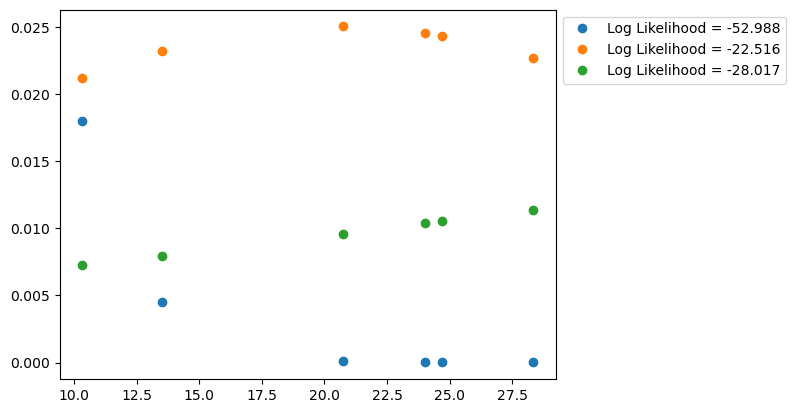

In [11]:
plt.plot(exp_data_filtered.values, expit(func(exp_data_filtered)), 'o', label=("Log Likelihood = %.3f" % log_likelyhood))
plt.plot(exp_data_filtered.values, expit(func5Cl(exp_data_filtered)), 'o', label=("Log Likelihood = %.3f" % log_likelyhood5Cl))
plt.plot(exp_data_filtered.values, expit(func10Cl(exp_data_filtered)), 'o', label=("Log Likelihood = %.3f" % log_likelyhood10Cl))
plt.legend(loc='upper left', bbox_to_anchor=(1., 1.))